In [126]:
print('hi')

hi


In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve)

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

import warnings
warnings.filterwarnings('ignore')

In [128]:
df_org = pd.read_csv(r'dataset/credit_dataset.csv')
df_org.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [129]:
df_org.shape

(32581, 12)

In [130]:
df_org.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

In [131]:
df_org.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [132]:
df_org.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [133]:
df_org[['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']].head()

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
0,RENT,PERSONAL,D,Y
1,OWN,EDUCATION,B,N
2,MORTGAGE,MEDICAL,C,N
3,RENT,MEDICAL,C,N
4,RENT,MEDICAL,C,Y


In [134]:
df_org['loan_status'].unique()

array([1, 0])

In [135]:
df_org['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

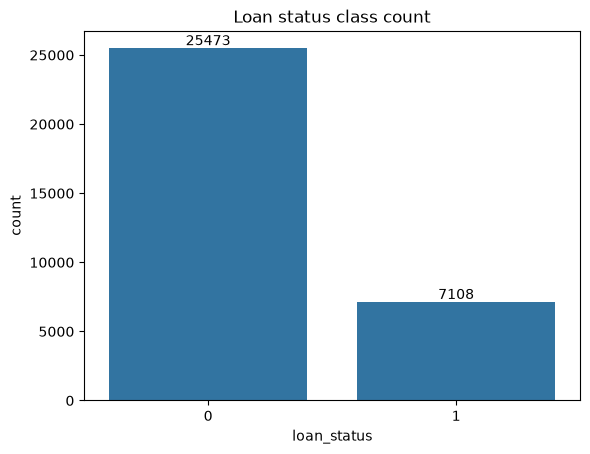

In [136]:
ax = sns.countplot(x = df_org['loan_status'])

for container in ax.containers:
    ax.bar_label(container)


plt.title('Loan status class count')
plt.show()

In [137]:

numerical_cols = df_org.select_dtypes(include=np.number).columns
numerical_cols = numerical_cols.drop('loan_status')
numerical_cols

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='str')

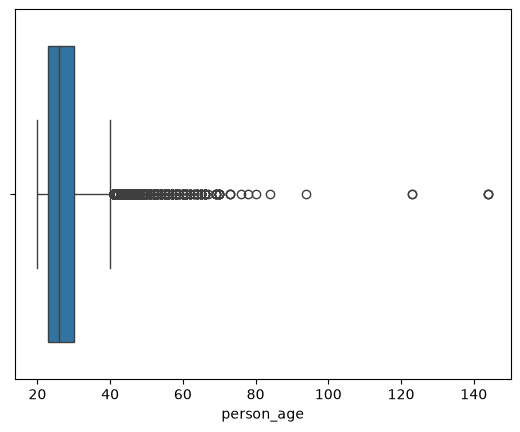

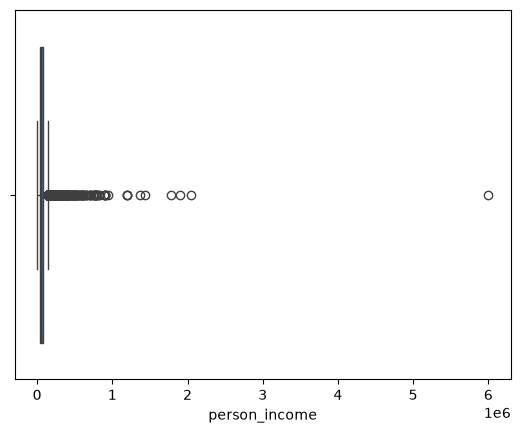

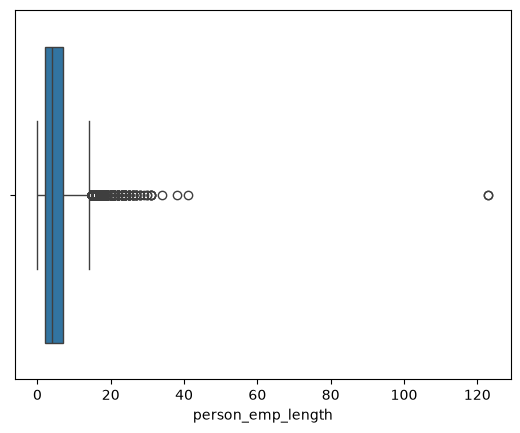

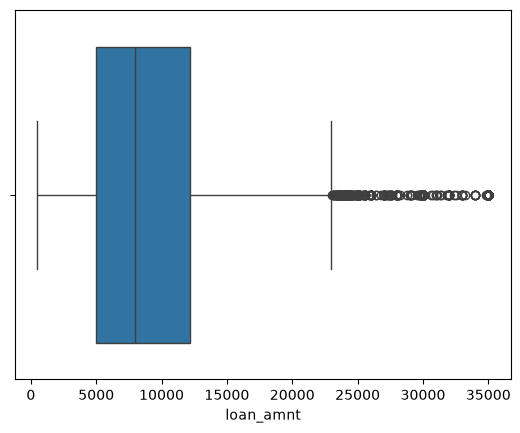

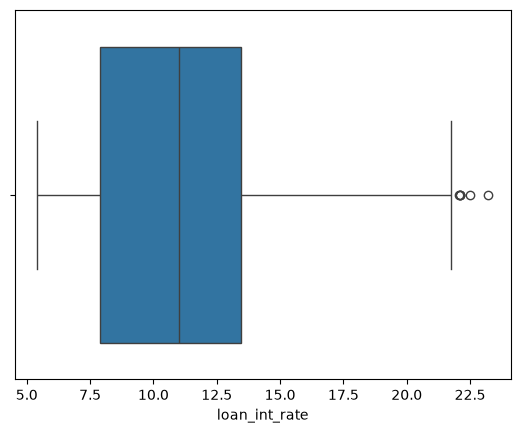

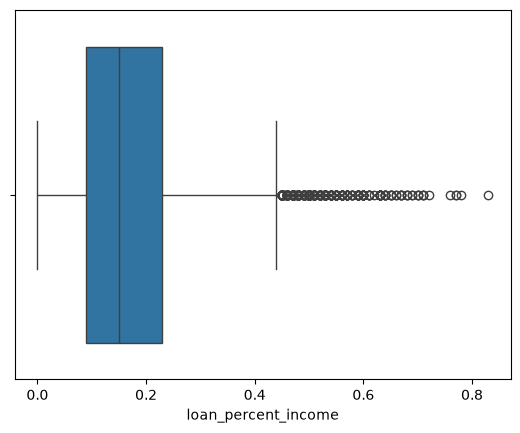

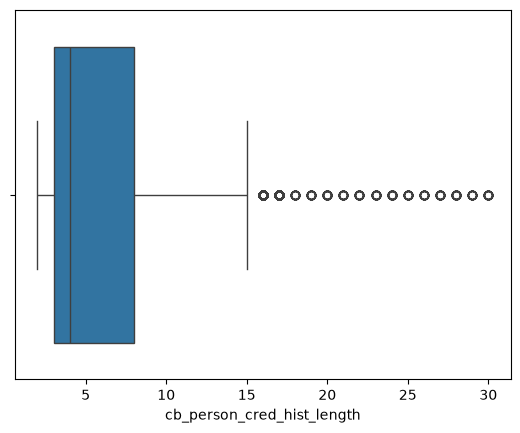

In [138]:
for i in numerical_cols:
    sns.boxplot(x = df_org[i])
    plt.show()

In [139]:
df_org.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [140]:
(df_org['person_age']>100).sum()

np.int64(5)

In [141]:
(df_org['person_emp_length']>60).sum()

np.int64(2)

<Axes: >

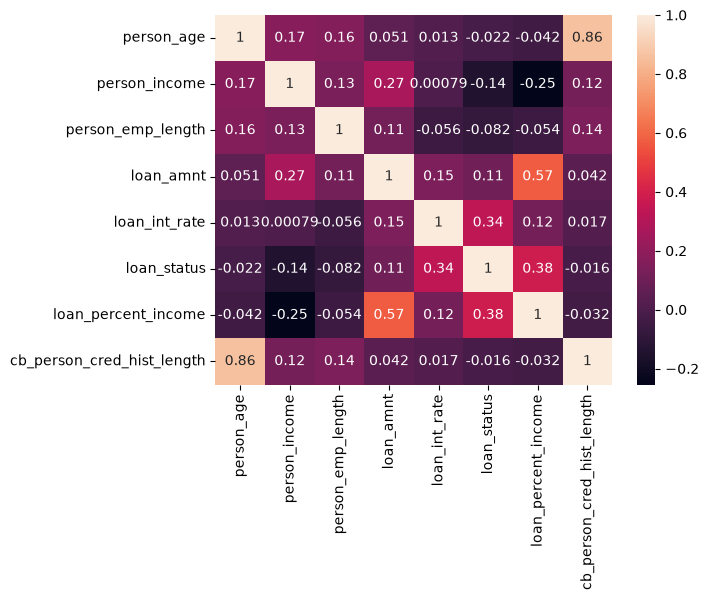

In [142]:
sns.heatmap(df_org.corr(numeric_only=True),annot=True)

In [143]:
df = df_org.copy()

In [144]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [145]:
df.shape

(32581, 12)

In [146]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [147]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [148]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [149]:
df.drop_duplicates(inplace=True)
df.shape

(32416, 12)

In [150]:
df = df[df['person_age']>=18]
df = df[df['person_age']<=100]

In [151]:
(df['person_age']>=100).sum()

np.int64(0)

In [152]:
df = df[(df['person_emp_length'] <= df['person_age'])]
df = df[df['person_emp_length']<=60]


In [153]:
df =df[df['loan_amnt']>0]

In [154]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

In [155]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [156]:
X.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,0.25,N,2


In [157]:
y.head()

1    0
2    1
3    1
4    1
5    1
Name: loan_status, dtype: int64

In [158]:
numerical_cols = X.select_dtypes(include=np.number).columns
numerical_cols

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='str')

In [159]:
df.info()

<class 'pandas.DataFrame'>
Index: 31522 entries, 1 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  31522 non-null  int64  
 1   person_income               31522 non-null  int64  
 2   person_home_ownership       31522 non-null  str    
 3   person_emp_length           31522 non-null  float64
 4   loan_intent                 31522 non-null  str    
 5   loan_grade                  31522 non-null  str    
 6   loan_amnt                   31522 non-null  int64  
 7   loan_int_rate               28495 non-null  float64
 8   loan_status                 31522 non-null  int64  
 9   loan_percent_income         31522 non-null  float64
 10  cb_person_default_on_file   31522 non-null  str    
 11  cb_person_cred_hist_length  31522 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.1 MB


In [160]:
categorical_cols = X.select_dtypes(include=str).columns
categorical_cols

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='str')

In [161]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [162]:
y.value_counts()
negative, positive = np.bincount(y_train)

scale_weight = negative/positive
scale_weight

np.float64(3.6312213039485766)

In [163]:
preprocessor_lgr = ColumnTransformer(
    transformers=[
        #pipeline - numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]),numerical_cols),
        
        #pipelines - categorical cols
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='N/A')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

In [164]:
preprocessor_xgb = ColumnTransformer(
    transformers=[
        #pipeline - numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
        ]), numerical_cols),
        
        #pipelines - categorical cols
        ('cat',Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='N/A')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]),categorical_cols)
    ]
)

In [165]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'roc_auc':'roc_auc', 'accuracy': 'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}

In [166]:
lgr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lgr),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

In [167]:
xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xgb),
    ('classifier', XGBClassifier(
        n_estimator = 300, max_depth = 5, learning_rate = 0.1,
        scale_pos_weight = scale_weight, random_state = 42
    ))
])

In [168]:
for cv_name, pipe in [('Logistic Regression', lgr_cv_pipeline), ('XGBoost', xgb_cv_pipeline)]:
    cv_result = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    print(cv_name)
    
    print('ROC_AUC_SCORE:', cv_result['test_roc_auc'].mean())
    print('ACURRACY:', cv_result['test_accuracy'].mean())
    print('PRECISION:', cv_result['test_precision'].mean())
    print('RECALL:', cv_result['test_recall'].mean())
    print('F1_SCORE:', cv_result['test_f1'].mean())
    print()


Logistic Regression
ROC_AUC_SCORE: 0.8705112830525306
ACURRACY: 0.8115949542892269
PRECISION: 0.5448226008889892
RECALL: 0.7781450872359963
F1_SCORE: 0.6408013995933108

XGBoost
ROC_AUC_SCORE: 0.9393848243386111
ACURRACY: 0.9086724038455642
PRECISION: 0.7913354492271174
RECALL: 0.7856749311294765
F1_SCORE: 0.7880291923045915



In [169]:
baseLineModel = Pipeline([
    ('preprocessor', preprocessor_lgr),
    ('classifier', LogisticRegression(class_weight='balanced'))
])

baseLineModel.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['person_age','person_income','person_home_ownership',..., 'loan_percent_income','cb_person_default_on_file', 'cb_person_cred_hist_length']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped

In [170]:
xgb_model = Pipeline([
    ('preprocessor', preprocessor_xgb),
    ('classifier', XGBClassifier(learning_rate = 0.1, scale_pos_weight = scale_weight, random_state = 42))
])

xgb_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['person_age','person_income','person_home_ownership',..., 'loan_percent_income','cb_person_default_on_file', 'cb_person_cred_hist_length']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped

In [171]:
def modelEvaluater(model_name,model, X_test, y_test, thresold = None):
    y_pred_prob = model.predict_proba(X_test)[:,1]
    
    if thresold:
        y_pred = (y_pred_prob>thresold).astype(int)
    else:
        y_pred = model.predict(X_test)
        
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1Score = f1_score(y_test,y_pred)
    
    conf_matrix = confusion_matrix(y_test,y_pred)
    class_report = classification_report(y_test,y_pred)
    
    print(f'{model_name} Metrics:')
    
    if thresold is not None:
        print(f'Used Thresold: {thresold:.2f}')
    print(f'Acurracy: {accuracy:.2f}')
    print(f'Precision: {precision:.2f}')
    print(f'Recall: {recall:.2f}')
    print(f'f1 Score: {f1Score:.2f}')
    
    print()
    print(f'Confusion Matrix: \n {conf_matrix}')
    print(f'Classification Report: \n {class_report}')
    
    sns.heatmap(conf_matrix, annot=True)
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('Actual Value')
    plt.xlabel('Predicted Value')
    plt.show()
    
    
    precision, recall, thresold = precision_recall_curve(y_test, y_pred_prob)
    plt.plot(recall, precision)
    plt.ylabel('Precision')
    plt.xlabel('Recall')
    plt.show()

Baseline Logistic Model Metrics:
Acurracy: 0.82
Precision: 0.56
Recall: 0.79
f1 Score: 0.65

Confusion Matrix: 
 [[4094  849]
 [ 290 1072]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



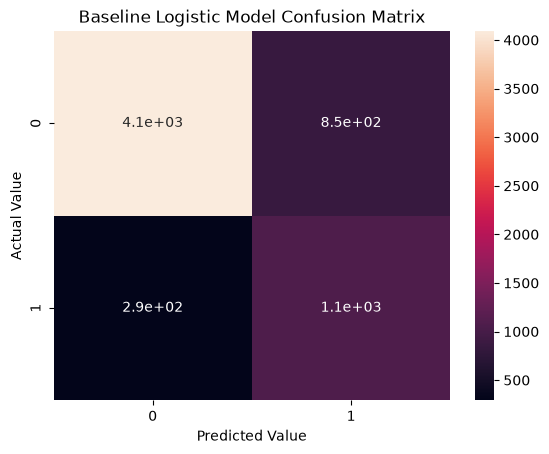

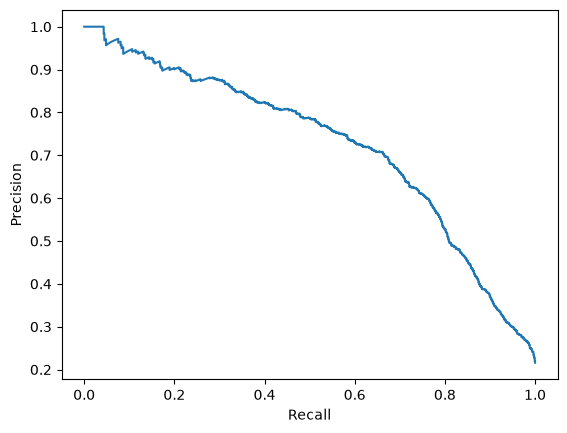

In [172]:
modelEvaluater('Baseline Logistic Model', baseLineModel, X_test, y_test)

XGBoost Metrics:
Acurracy: 0.92
Precision: 0.82
Recall: 0.79
f1 Score: 0.81

Confusion Matrix: 
 [[4711  232]
 [ 281 1081]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.94      0.95      0.95      4943
           1       0.82      0.79      0.81      1362

    accuracy                           0.92      6305
   macro avg       0.88      0.87      0.88      6305
weighted avg       0.92      0.92      0.92      6305



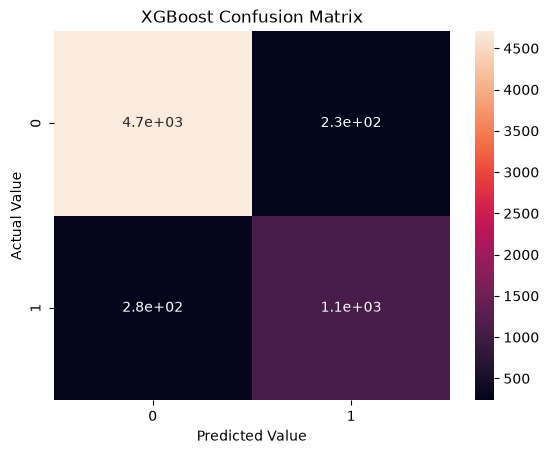

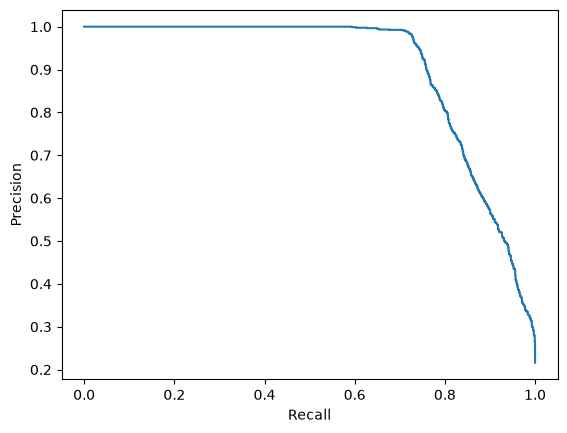

In [173]:
modelEvaluater('XGBoost', xgb_model, X_test, y_test)

In [177]:

param_grid = {
    "classifier__n_estimators": randint(150, 600),
    "classifier__max_depth": randint(3, 9),
    "classifier__learning_rate": uniform(0.01, 0.49),
    "classifier__subsample": uniform(0.6, 0.4),
    "classifier__colsample_bytree": uniform(0.6, 0.4),
    "classifier__min_child_weight": randint(1, 10),
    "classifier__gamma": uniform(0, 5),
}
#lower gamma -> more split
#higher gamma -> less split

In [178]:
random_search = RandomizedSearchCV(
    xgb_model,
    param_grid,
    n_iter=150,
    cv =cv,
    scoring = 'average_precision',
    n_jobs=-1,
    verbose=1
)



In [179]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': <scipy.stats....00215CD72ED50>, 'classifier__gamma': <scipy.stats....00215CD72F350>, 'classifier__learning_rate': <scipy.stats....00215CD9FCE20>, 'classifier__max_depth': <scipy.stats....00215CD72EC50>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",150
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index

In [ ]:
f'{random_search.best_score_:.2f}'

'0.90'

In [183]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.9694706575236994),
 'classifier__gamma': np.float64(1.7695688229190782),
 'classifier__learning_rate': np.float64(0.1513456410122794),
 'classifier__max_depth': 4,
 'classifier__min_child_weight': 4,
 'classifier__n_estimators': 514,
 'classifier__subsample': np.float64(0.8709304526398811)}

XGBoost Metrics:
Acurracy: 0.92
Precision: 0.80
Recall: 0.81
f1 Score: 0.81

Confusion Matrix: 
 [[4668  275]
 [ 257 1105]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.95      0.94      0.95      4943
           1       0.80      0.81      0.81      1362

    accuracy                           0.92      6305
   macro avg       0.87      0.88      0.88      6305
weighted avg       0.92      0.92      0.92      6305



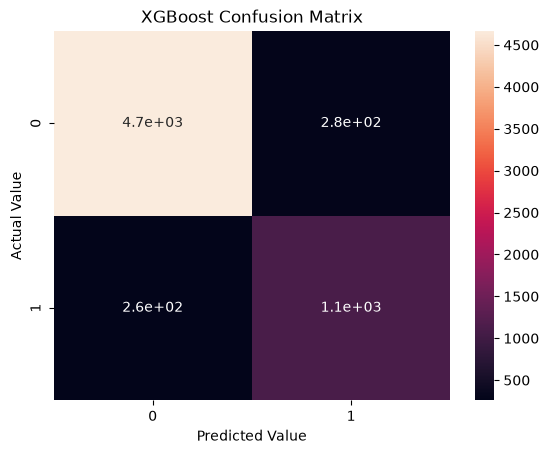

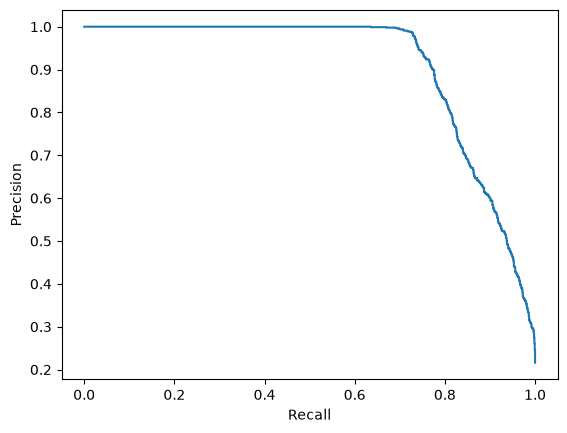

In [184]:
modelEvaluater('XGBoost', random_search, X_test,  y_test)